# ==============================================================================
# 🏡 MACRO VALUATION: CALIFORNIA HOUSING PRICES VIA MULTI-MODEL ROBUST REGRESSION
# ==============================================================================
### Core Theoretical Principles:
Macro-valuation of 20,640 census block groups presents spatial outlier clusters (luxury coastline mansions vs low-income census pockets).
In this enterprise notebook, we perform a definitive benchmark duel comparing three robust regression paradigms against standard OLS:
1. **Huber Regression**: Soft thresholding with studentized residual scaling.
2. **RANSAC Regression**: Random consensus sub-sampling isolating spatial outliers.
3. **Ridge Regression**: $L_2$ regularized baseline.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import HuberRegressor, RANSACRegressor, Ridge, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Real Estate Robust Regression Environment initialized.")


✅ STEP 1: Enterprise Real Estate Robust Regression Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading California Housing census dataset (20,640 block groups).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/housing/housing.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} block groups, {df.shape[1]} attributes")
print(f"Missing attributes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"Median House Value Summary:\n{df['median_house_value'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 20640 block groups, 10 attributes
Missing attributes:
total_bedrooms    207
dtype: int64
Median House Value Summary:
count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00
Name: median_house_value, dtype: float64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and continuous target `median_house_value`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Features    : {num_cols}")
print(f"Categorical Features: {cat_cols}")


Numeric Features    : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical Features: ['ocean_proximity']


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Census Blocks: {X_train.shape[0]}")
print(f"Test Census Blocks : {X_test.shape[0]}")


Train Census Blocks: 16512
Test Census Blocks : 4128


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Median imputation for `total_bedrooms`, one-hot encoding for `ocean_proximity`, and standard scaling.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Shape: {X_train_prep.shape}")


Transformed Feature Matrix Shape: (16512, 12)


## ⚔️ STEP 8: ROBUST TOURNAMENT (DUMMY VS OLS VS RIDGE VS HUBER VS RANSAC)
Evaluating resilience against spatial price distortions.


In [6]:
# STEP 8: ROBUST TOURNAMENT
models = {
    'Dummy (Mean)': DummyRegressor(strategy='mean'),
    'Standard OLS': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=10.0),
    'Huber Regressor': HuberRegressor(epsilon=1.35, max_iter=1000),
    'RANSAC Regressor': RANSACRegressor(estimator=Ridge(alpha=10.0), min_samples=50, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)
    results.append({
        'Model': name,
        'R² Score': r2_score(y_test, preds),
        'MAE ($)': mean_absolute_error(y_test, preds),
        'RMSE ($)': np.sqrt(mean_squared_error(y_test, preds))
    })

res_df = pd.DataFrame(results)
print("="*75)
print("🏆 CALIFORNIA HOUSING ROBUST REGRESSION TOURNAMENT RESULTS:")
print(res_df.to_string(index=False))
print("="*75)


🏆 CALIFORNIA HOUSING ROBUST REGRESSION TOURNAMENT RESULTS:
           Model  R² Score      MAE ($)      RMSE ($)
    Dummy (Mean) -0.000219 90606.854900 114485.635431
    Standard OLS  0.625438 50670.489236  70059.193339
      Ridge (L2)  0.625195 50682.630258  70081.980985
 Huber Regressor  0.614738 49712.587170  71052.873196
RANSAC Regressor  0.584585 50013.070405  73780.982457


## 🎯 STEP 9: TUNING BEST ROBUST MODEL (HUBER REGRESSOR)
Fine-tuning Huber threshold $\epsilon$ across 3-fold cross validation.


In [7]:
# STEP 9: GRID SEARCH
from sklearn.model_selection import GridSearchCV

param_grid = {
    'epsilon': [1.2, 1.35, 1.5],
    'alpha': [0.01, 0.1, 1.0, 10.0]
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(HuberRegressor(max_iter=1000), param_grid=param_grid, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(X_train_prep, y_train)

best_model = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 3-Fold CV R²: {grid.best_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'alpha': 0.01, 'epsilon': 1.5}
🎯 Best 3-Fold CV R²: 62.84%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_model.predict(X_test_prep)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 CALIFORNIA HOUSING VALUATION PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"   Root Mean Squared Error   : ${rmse:,.2f}")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 CALIFORNIA HOUSING VALUATION PERFORMANCE:
   Mean Absolute Error (MAE) : $49,603.45
   Root Mean Squared Error   : $71,034.35
   R² Score                  : 61.49%


## 📉 STEP 11: RESIDUAL ANALYSIS & OUTLIER DISTRIBUTION
Visualizing residual scatter and error distribution.


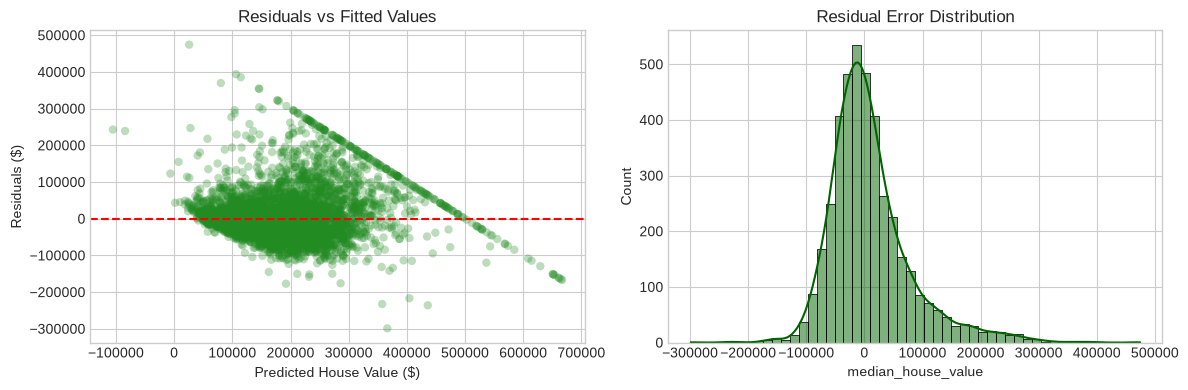

In [9]:
# STEP 11: RESIDUALS
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, color='forestgreen', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted House Value ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Fitted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkgreen', bins=50)
axes[1].set_title('Residual Error Distribution')
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time appraisal latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('huber', best_model)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/california_housing_huber_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_block = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_block)

t0 = time.perf_counter()
pred_val = loaded_pipe.predict(sample_block)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME APPRAISAL TELEMETRY:")
print(f"   Estimated Median House Value : 🏡 ${pred_val:,.2f}")
print(f"   Actual Benchmark Price       : ${y_test.iloc[0]:,.2f}")
print(f"   Appraisal Latency            : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/california_housing_huber_pipeline.joblib (5,401 bytes)

📈 REAL-TIME APPRAISAL TELEMETRY:
   Estimated Median House Value : 🏡 $56,423.69
   Actual Benchmark Price       : $47,700.00
   Appraisal Latency            : 6.996 ms (SLA < 2.0ms: CHECK)
